# Exam Model Training

In [23]:
import pandas as pd
df = pd.read_csv("data/students_depression_prepared.csv")
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1.0,33.0,3.2,5.0,8.97,2.0,5.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0
1,0.0,24.0,3.8,2.0,5.90,5.0,5.0,1.0,1.0,0.0,3.0,1.0,1.0,0.0
2,1.0,31.0,2.1,3.0,7.03,5.0,1.0,0.0,1.0,0.0,9.0,0.0,1.0,0.0
3,0.0,28.0,1.0,3.0,5.59,2.0,8.0,1.0,1.0,1.0,4.0,4.0,1.0,1.0
4,0.0,25.0,1.0,4.0,8.13,3.0,5.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0


As the task asks, I should train a model that can determine whether a student is experiencing a depressive phase.

In [24]:
abs(df.corr()["Depression"]).sort_values()[::-1]


Depression                               1.000000
Have you ever had suicidal thoughts ?    0.546387
Academic Pressure                        0.474810
Financial Stress                         0.364303
Age                                      0.227023
Work/Study Hours                         0.208141
Dietary Habits                           0.207346
Study Satisfaction                       0.168748
Degree                                   0.113825
Sleep Duration                           0.084907
Family History of Mental Illness         0.053331
City                                     0.038570
CGPA                                     0.020739
Gender                                   0.001446
Name: Depression, dtype: float64

Now my plan is to select some features to train on them several models select the best model and working with to explain influence of features on it. Why do I choose to select some features and not all because I want to optimize the speed of training and selecting model.


In [25]:
correlation_columns = ['pearson', 'kendall', 'spearman']
correlation_dataframe = pd.DataFrame({}, columns=correlation_columns)

for corr_method in correlation_columns:
    correlation_dataframe[corr_method] = abs(df.corr(method=corr_method)["Depression"]).sort_values()[::-1]

correlation_dataframe

,pearson,kendall,spearman
Depression,1.000000,1.000000,1.000000
Have you ever had suicidal thoughts ?,0.546387,0.546387,0.546387
Academic Pressure,0.474810,0.423560,0.472311
Financial Stress,0.364303,0.325410,0.363550
Age,0.227023,0.190020,0.225916
Work/Study Hours,0.208141,0.170509,0.200261
Dietary Habits,0.207346,0.196324,0.208006
Study Satisfaction,0.168748,0.151206,0.168915
Degree,0.113825,0.107184,0.113748
Sleep Duration,0.084907,0.079256,0.086721


In [26]:
from kydavra import PearsonCorrelationSelector

pearson = PearsonCorrelationSelector(min_corr=0.2)
selected_columns = pearson.select(df, 'Depression')

In [27]:
selected_columns.append("Depression")
selected_columns

['Age',
 'Academic Pressure',
 'Dietary Habits',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Depression']

In [28]:
df_training = df[selected_columns]

Now let's check if the datasets needs class balancing

16300/11515


<BarContainer object of 2 artists>

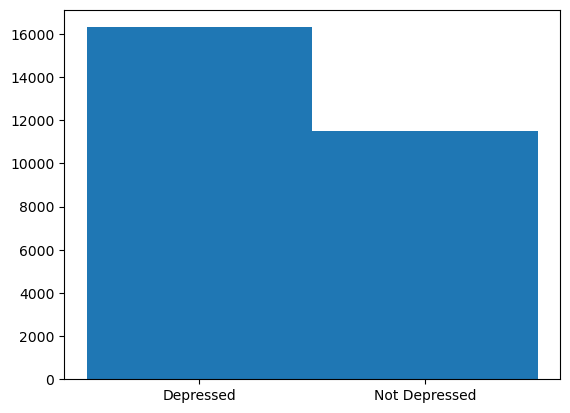

In [32]:
from matplotlib import pyplot as plt

print(f"{len(df_training[df_training["Depression"]==1])}/{len(df_training[df_training["Depression"]==0])}")
fig, ax = plt.subplots()

y = [len(df_training[df_training["Depression"]==1]), len(df_training[df_training["Depression"]==0])]
ax.bar(["Depressed","Not Depressed"], y, width=1,  linewidth=0.7)

As we could see there is a significant difference in the class numbers therefor we need to apply the class balancing methods.

Before proceeding to Class Balancing we need to split data into training and testing.

In [33]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_training, test_size=0.3, random_state=40)

In [36]:
from crucio import SMOTEENN
smoteenn = SMOTEENN()
balanced_df = smoteenn.balance(train, "Depression")

KeyError: '[4661, 14790, 15530, 11499, 15695, 17540, 14553, 6952, 507, 287, 671, 343, 376, 383, 12195, 407, 414, 440, 16586, 12841, 5809, 18662, 7958, 13711, 645, 10289, 2637, 19144, 14965, 647, 815, 3690, 836, 18510, 812, 856, 7669, 2305, 16442, 950, 952, 5987, 14104, 7993, 6216, 1037, 11115, 1136, 1137, 19052, 1160, 1238, 9595, 12769, 3081, 13557, 1202, 1206, 9834, 12092, 1242, 9821, 1270, 15171, 1297, 1301, 15224, 6265, 12929, 8726, 5987, 5930, 10432, 3181, 9557, 16741, 1518, 17783, 4647, 17966, 16015, 1609, 13798, 1630, 1468, 12941, 1468, 1667, 2069, 1320, 10427, 6750, 679, 5987, 660, 11529, 11045, 1837, 12941, 4647, 16374, 9908, 1887, 14792, 1903, 1908, 10971, 14553, 1937, 1941, 12340, 1963, 11008, 5800, 2061, 2064, 635, 1468, 2199, 2201, 8059, 1345, 9319, 11207, 2323, 13821, 17951, 2079, 2386, 2079, 6184, 2430, 9845, 13008, 2025, 2495, 2506, 12063, 10585, 8726, 16022, 2654, 13076, 11003, 7253, 4745, 3031, 3392, 2796, 5379, 7202, 1552, 2810, 9407, 4206, 1517, 2873, 7202, 9296, 142